# SigLIP2 furniture taxonomy A/B comparison

Train two independently initialized SigLIP2 head-tuning runs on the same furniture ASINs and images:

- **Model A — original:** uses the original product description.
- **Model B — taxonomy enriched:** prepends the full furniture taxonomy to the same description.

Everything else is held constant: split map, sampled ASINs, batch order, base checkpoint, seed, optimizer, batch size, epoch count, and evaluation catalog. Primary evaluation uses original natural descriptions for both models.

## 0. Environment and bounded experiment controls

Select **RecSystem — SigLIP2 (Python 3.11)**. The defaults are a local smoke comparison, not a final model-selection run.

In [1]:
from contextlib import nullcontext
from pathlib import Path
import gc
import json
import platform
import random
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModel, AutoProcessor

SEED = 42
MODEL_ID = "google/siglip2-base-patch16-224"
TRAIN_ROWS = 64
EVAL_ROWS = 64
CATALOG_ROWS = 250
EPOCHS = 1
TRAIN_BATCH_SIZE = 4
ENCODE_BATCH_SIZE = 4
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 0.01
MAX_GRAD_NORM = 1.0
MAX_TEXT_LENGTH = 64
TOP_K = 10
TEXT_QUERY = "mid-century modern walnut coffee table for a living room"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
PIN_MEMORY = DEVICE.type == "cuda"
print({
    "python": platform.python_version(),
    "executable": sys.executable,
    "device": str(DEVICE),
    "torch": torch.__version__,
})
if sys.version_info[:2] != (3, 11):
    raise RuntimeError("Select the RecSystem — SigLIP2 (Python 3.11) kernel.")

{'python': '3.11.6', 'executable': '/Users/vachemacbook/Desktop/RecSystem/RecSystem/.venv-siglip2/bin/python', 'device': 'mps', 'torch': '2.2.2'}


## 1. Load and reconcile both text variants

The enriched file contains both original and enriched text. We also reconcile it against the original pairs file and reuse the existing 16k/2k/2k ASIN split.

In [2]:
ORIGINAL_RELATIVE_PATH = Path("data/meta_Home_and_Kitchen_furniture_siglip2_pairs_20k.csv")
ENRICHED_RELATIVE_PATH = Path("data/meta_Home_and_Kitchen_furniture_siglip2_pairs_20k_taxonomy_enriched.csv")
SPLIT_RELATIVE_PATH = Path("data/meta_Home_and_Kitchen_furniture_siglip2_splits_20k.csv")
CATALOG_COLUMNS = [
    "asin", "description_original", "taxonomy_text", "description_enriched",
    "image_path", "furniture_subcategory", "category_path",
]


def find_project_root(start):
    for candidate in (start, *start.parents):
        if (candidate / ENRICHED_RELATIVE_PATH).is_file():
            return candidate
    raise FileNotFoundError(f"Could not find {ENRICHED_RELATIVE_PATH} from {start}")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
ARTIFACT_DIR = PROJECT_ROOT / "models/siglip2_furniture_taxonomy_ab"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
original_df = pd.read_csv(PROJECT_ROOT / ORIGINAL_RELATIVE_PATH, dtype="string").fillna("")
df = pd.read_csv(PROJECT_ROOT / ENRICHED_RELATIVE_PATH, dtype="string").fillna("")
split_map = pd.read_csv(
    PROJECT_ROOT / SPLIT_RELATIVE_PATH, dtype={"asin": "string", "split": "string"}
)

assert set(CATALOG_COLUMNS).issubset(df.columns)
assert len(df) == len(original_df) == len(split_map) == 20_000
assert df["asin"].is_unique and original_df["asin"].is_unique and split_map["asin"].is_unique
reconciled = df[["asin", "description_original", "image_path"]].merge(
    original_df[["asin", "description", "image_path"]],
    on="asin", suffixes=("_enriched_file", "_original_file"), validate="one_to_one",
)
assert reconciled["description_original"].equals(reconciled["description"])
assert reconciled["image_path_enriched_file"].equals(reconciled["image_path_original_file"])
df["image_file"] = df["image_path"].map(lambda value: PROJECT_ROOT / value)
assert df["image_file"].map(Path.is_file).all()
assert df["description_original"].str.strip().ne("").all()
assert df["description_enriched"].str.strip().ne("").all()
assert df["taxonomy_text"].str.startswith("Furniture").all()
df = df.merge(split_map, on="asin", validate="one_to_one")
assert df["split"].value_counts().to_dict() == {"train": 16_000, "validation": 2_000, "test": 2_000}

train_df = df[df["split"].eq("train")].sample(n=TRAIN_ROWS, random_state=SEED).reset_index(drop=True)
eval_df = df[df["split"].eq("validation")].sample(n=EVAL_ROWS, random_state=SEED).reset_index(drop=True)
catalog_df = df[df["split"].eq("test")].sample(n=CATALOG_ROWS, random_state=SEED).reset_index(drop=True)
print({
    "rows": len(df),
    "training_pairs_per_model": len(train_df),
    "evaluation_pairs": len(eval_df),
    "catalog_products": len(catalog_df),
    "same_asins_for_both_models": True,
})
display(df[["asin", "taxonomy_text", "description_original", "description_enriched"]].head())

{'rows': 20000, 'training_pairs_per_model': 64, 'evaluation_pairs': 64, 'catalog_products': 250, 'same_asins_for_both_models': True}


,asin,taxonomy_text,description_original,description_enriched
0,B018NZJ75M,Furniture; Game & Recreation Room Furniture; H...,"Offer a warm, inviting look to your kitchen, d...",Furniture; Game & Recreation Room Furniture; H...
1,B082XWFB66,Furniture; Living Room Furniture; Ottomans,Inspired by the playful style of the Italian M...,Furniture; Living Room Furniture; Ottomans. In...
2,B0892Q8NLR,"Furniture; Bedroom Furniture; Beds, Frames & B...",Featuring classic design elements and plentifu...,"Furniture; Bedroom Furniture; Beds, Frames & B..."
3,B08D67VZFH,Furniture; Living Room Furniture; Chairs,"Features: Made of premium birch, solid constru...",Furniture; Living Room Furniture; Chairs. Feat...
4,B0B35BM8RQ,"Furniture; Bedroom Furniture; Beds, Frames & B...","The 1.5-inch Bunkie Board , Split Bunkie Board...","Furniture; Bedroom Furniture; Beds, Frames & B..."


## 2. Shared processor, datasets, and deterministic loaders

In [3]:
processor = AutoProcessor.from_pretrained(MODEL_ID)


def open_rgb(path):
    with Image.open(path) as image:
        return image.convert("RGB")


class FurniturePairs(Dataset):
    def __init__(self, frame, text_column):
        self.text_column = text_column
        self.records = frame[["asin", text_column, "image_file"]].to_dict("records")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        row = self.records[index]
        return {
            "asin": row["asin"],
            "text": row[self.text_column],
            "image": open_rgb(row["image_file"]),
        }


def collate_pairs(examples):
    batch = processor(
        text=[example["text"] for example in examples],
        images=[example["image"] for example in examples],
        padding="max_length", truncation=True, max_length=MAX_TEXT_LENGTH, return_tensors="pt",
    )
    batch["asins"] = [example["asin"] for example in examples]
    return batch


def make_loader(frame, text_column, batch_size, *, shuffle=False):
    return DataLoader(
        FurniturePairs(frame, text_column),
        batch_size=batch_size,
        shuffle=shuffle,
        generator=torch.Generator().manual_seed(SEED),
        num_workers=0, pin_memory=PIN_MEMORY, collate_fn=collate_pairs, drop_last=False,
    )


for text_column in ("description_original", "description_enriched"):
    sample = next(iter(make_loader(train_df, text_column, TRAIN_BATCH_SIZE, shuffle=True)))
    print(text_column, {key: tuple(value.shape) for key, value in sample.items() if key != "asins"})

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


description_original {'pixel_values': (4, 3, 224, 224), 'input_ids': (4, 64)}
description_enriched {'pixel_values': (4, 3, 224, 224), 'input_ids': (4, 64)}


## 3. Identical model initialization and evaluation helpers

Each variant loads a fresh copy of the same pretrained checkpoint. Both backbones are frozen; only the two heads and similarity calibration are trainable.

In [4]:
def reset_seeds():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)


def load_fresh_model():
    reset_seeds()
    model = AutoModel.from_pretrained(MODEL_ID).to(DEVICE)
    for parameter in model.parameters():
        parameter.requires_grad = False
    for module in (model.text_model.head, model.vision_model.head):
        for parameter in module.parameters():
            parameter.requires_grad = True
    model.logit_scale.requires_grad = True
    model.logit_bias.requires_grad = True
    return model


def move_tensors(batch):
    return {
        key: value.to(DEVICE, non_blocking=PIN_MEMORY)
        for key, value in batch.items() if key != "asins"
    }


def encode_pairs(model, frame, text_column, description):
    loader = make_loader(frame, text_column, ENCODE_BATCH_SIZE)
    all_asins, image_chunks, text_chunks = [], [], []
    model.eval()
    with torch.inference_mode():
        for batch in tqdm(loader, desc=description):
            all_asins.extend(batch["asins"])
            outputs = model(**move_tensors(batch), return_dict=True)
            image_chunks.append(F.normalize(outputs.image_embeds, dim=-1).cpu())
            text_chunks.append(F.normalize(outputs.text_embeds, dim=-1).cpu())
    return all_asins, torch.cat(image_chunks), torch.cat(text_chunks)


def paired_recall(image_embeddings, text_embeddings, ks=(1, 5, 10)):
    similarities = image_embeddings @ text_embeddings.T
    targets = torch.arange(len(similarities))
    image_ranked = similarities.argsort(dim=1, descending=True)
    text_ranked = similarities.T.argsort(dim=1, descending=True)
    metrics = {}
    for k in ks:
        effective_k = min(k, len(similarities))
        metrics[f"image_to_text_recall@{k}"] = (
            (image_ranked[:, :effective_k] == targets[:, None]).any(1).float().mean().item()
        )
        metrics[f"text_to_image_recall@{k}"] = (
            (text_ranked[:, :effective_k] == targets[:, None]).any(1).float().mean().item()
        )
    return metrics


def release_model(model):
    del model
    gc.collect()
    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    elif DEVICE.type == "cuda":
        torch.cuda.empty_cache()

## 4. Shared pretrained baseline

The baseline is computed once because both A/B runs start from the same checkpoint. Original-description metrics are primary; enriched-description metrics show how much the taxonomy itself simplifies pairing.

In [5]:
baseline_model = load_fresh_model()
_, baseline_images, baseline_original_text = encode_pairs(
    baseline_model, eval_df, "description_original", "Baseline — original text"
)
_, _, baseline_enriched_text = encode_pairs(
    baseline_model, eval_df, "description_enriched", "Baseline — enriched text"
)
baseline_original_metrics = paired_recall(baseline_images, baseline_original_text)
baseline_enriched_metrics = paired_recall(baseline_images, baseline_enriched_text)
display(pd.DataFrame({
    "original_text": baseline_original_metrics,
    "enriched_text": baseline_enriched_metrics,
}))
del baseline_model
gc.collect()
if DEVICE.type == "mps":
    torch.mps.empty_cache()
elif DEVICE.type == "cuda":
    torch.cuda.empty_cache()

Baseline — original text:   0%|          | 0/16 [00:00<?, ?it/s]

Baseline — enriched text:   0%|          | 0/16 [00:00<?, ?it/s]

,original_text,enriched_text
image_to_text_recall@1,0.546875,0.421875
text_to_image_recall@1,0.500000,0.406250
image_to_text_recall@5,0.671875,0.609375
text_to_image_recall@5,0.703125,0.640625
image_to_text_recall@10,0.765625,0.671875
text_to_image_recall@10,0.781250,0.656250


## 5. Train each text variant sequentially

Sequential execution prevents both 375M-parameter models from occupying memory simultaneously. The function saves each head checkpoint before releasing the model.

In [6]:
def embed_text(model, query):
    inputs = processor(
        text=[query], padding="max_length", truncation=True,
        max_length=MAX_TEXT_LENGTH, return_tensors="pt",
    )
    with torch.inference_mode():
        embedding = model.get_text_features(
            **{key: value.to(DEVICE) for key, value in inputs.items()}
        )
    return F.normalize(embedding, dim=-1).cpu()[0]


def ranked_catalog_results(scores, k=TOP_K, exclude_index=None):
    scores = scores.clone()
    if exclude_index is not None:
        scores[exclude_index] = -torch.inf
    values, indices = scores.topk(min(k, len(scores) - (exclude_index is not None)))
    results = catalog_df.iloc[indices.tolist()][CATALOG_COLUMNS].copy()
    results.insert(1, "score", values.numpy())
    return results.reset_index(drop=True)


def train_variant(variant_name, training_text_column):
    model = load_fresh_model()
    trainable_names = [name for name, parameter in model.named_parameters() if parameter.requires_grad]
    trainable_count = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
    train_loader = make_loader(
        train_df, training_text_column, TRAIN_BATCH_SIZE, shuffle=True
    )
    optimizer = torch.optim.AdamW(
        [parameter for parameter in model.parameters() if parameter.requires_grad],
        lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
    )
    use_amp = DEVICE.type == "cuda"
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    history = []
    started_at = time.perf_counter()
    for epoch in range(EPOCHS):
        model.train()
        losses = []
        for batch in tqdm(train_loader, desc=f"Training {variant_name} epoch {epoch + 1}"):
            optimizer.zero_grad(set_to_none=True)
            autocast_context = torch.autocast("cuda", dtype=torch.float16) if use_amp else nullcontext()
            with autocast_context:
                loss = model(**move_tensors(batch), return_loss=True, return_dict=True).loss
            if not torch.isfinite(loss):
                raise FloatingPointError(f"Non-finite {variant_name} loss: {loss.item()}")
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                [parameter for parameter in model.parameters() if parameter.requires_grad],
                MAX_GRAD_NORM,
            )
            scaler.step(optimizer)
            scaler.update()
            losses.append(loss.item())
        history.append({
            "epoch": epoch + 1, "mean_loss": float(np.mean(losses)),
            "first_loss": float(losses[0]), "last_loss": float(losses[-1]),
        })
    elapsed_seconds = time.perf_counter() - started_at

    _, eval_images, eval_original_text = encode_pairs(
        model, eval_df, "description_original", f"{variant_name} — original evaluation"
    )
    _, _, eval_enriched_text = encode_pairs(
        model, eval_df, "description_enriched", f"{variant_name} — enriched evaluation"
    )
    catalog_asins, catalog_images, catalog_original_text = encode_pairs(
        model, catalog_df, "description_original", f"{variant_name} — catalog"
    )
    assert catalog_asins == catalog_df["asin"].tolist()
    query_embedding = embed_text(model, TEXT_QUERY)
    text_query_results = ranked_catalog_results(catalog_images @ query_embedding)
    image_query_scores = catalog_images @ catalog_images[0]
    image_query_results = ranked_catalog_results(image_query_scores, exclude_index=0)

    checkpoint_path = ARTIFACT_DIR / f"{variant_name}_heads.pt"
    trainable_state = {
        name: parameter.detach().cpu()
        for name, parameter in model.named_parameters() if name in trainable_names
    }
    torch.save(trainable_state, checkpoint_path)
    result = {
        "variant": variant_name,
        "training_text_column": training_text_column,
        "trainable_parameters": trainable_count,
        "history": history,
        "elapsed_seconds": elapsed_seconds,
        "original_metrics": paired_recall(eval_images, eval_original_text),
        "enriched_metrics": paired_recall(eval_images, eval_enriched_text),
        "image_embeddings": catalog_images,
        "description_embeddings": catalog_original_text,
        "text_query_results": text_query_results,
        "image_query_results": image_query_results,
        "checkpoint_path": checkpoint_path,
    }
    print({
        "variant": variant_name, "history": history,
        "elapsed_seconds": round(elapsed_seconds, 1),
    })
    del trainable_state
    release_model(model)
    return result

In [7]:
original_result = train_variant("original", "description_original")

Training original epoch 1:   0%|          | 0/16 [00:00<?, ?it/s]

original — original evaluation:   0%|          | 0/16 [00:00<?, ?it/s]

original — enriched evaluation:   0%|          | 0/16 [00:00<?, ?it/s]

original — catalog:   0%|          | 0/63 [00:00<?, ?it/s]

{'variant': 'original', 'history': [{'epoch': 1, 'mean_loss': 3.931115709245205, 'first_loss': 9.680282592773438, 'last_loss': 1.5064527988433838}], 'elapsed_seconds': 5.2}


In [8]:
taxonomy_result = train_variant("taxonomy", "description_enriched")

Training taxonomy epoch 1:   0%|          | 0/16 [00:00<?, ?it/s]

taxonomy — original evaluation:   0%|          | 0/16 [00:00<?, ?it/s]

taxonomy — enriched evaluation:   0%|          | 0/16 [00:00<?, ?it/s]

taxonomy — catalog:   0%|          | 0/63 [00:00<?, ?it/s]

{'variant': 'taxonomy', 'history': [{'epoch': 1, 'mean_loss': 4.59068357758224, 'first_loss': 12.33736801147461, 'last_loss': 2.293826103210449}], 'elapsed_seconds': 4.2}


## 6. Compare performance

The primary table compares both trained models on original natural descriptions. The secondary table uses taxonomy-enriched descriptions and should be interpreted as label-assisted performance.

In [9]:
primary_comparison = pd.DataFrame({
    "pretrained": baseline_original_metrics,
    "trained_original": original_result["original_metrics"],
    "trained_taxonomy": taxonomy_result["original_metrics"],
})
primary_comparison["taxonomy_minus_original"] = (
    primary_comparison["trained_taxonomy"] - primary_comparison["trained_original"]
)
secondary_comparison = pd.DataFrame({
    "pretrained": baseline_enriched_metrics,
    "trained_original": original_result["enriched_metrics"],
    "trained_taxonomy": taxonomy_result["enriched_metrics"],
})
secondary_comparison["taxonomy_minus_original"] = (
    secondary_comparison["trained_taxonomy"] - secondary_comparison["trained_original"]
)
print("Primary — original natural descriptions")
display(primary_comparison)
print("Secondary diagnostic — taxonomy-enriched descriptions")
display(secondary_comparison)
display(pd.DataFrame({
    "training_text": ["original", "taxonomy enriched"],
    "elapsed_seconds": [original_result["elapsed_seconds"], taxonomy_result["elapsed_seconds"]],
    "mean_loss": [original_result["history"][-1]["mean_loss"], taxonomy_result["history"][-1]["mean_loss"]],
    "last_loss": [original_result["history"][-1]["last_loss"], taxonomy_result["history"][-1]["last_loss"]],
}))

Primary — original natural descriptions


,pretrained,trained_original,trained_taxonomy,taxonomy_minus_original
image_to_text_recall@1,0.546875,0.515625,0.515625,0.000000
text_to_image_recall@1,0.500000,0.500000,0.484375,-0.015625
image_to_text_recall@5,0.671875,0.718750,0.718750,0.000000
text_to_image_recall@5,0.703125,0.703125,0.703125,0.000000
image_to_text_recall@10,0.765625,0.765625,0.796875,0.031250
text_to_image_recall@10,0.781250,0.781250,0.781250,0.000000


Secondary diagnostic — taxonomy-enriched descriptions


,pretrained,trained_original,trained_taxonomy,taxonomy_minus_original
image_to_text_recall@1,0.421875,0.406250,0.406250,0.000000
text_to_image_recall@1,0.406250,0.421875,0.421875,0.000000
image_to_text_recall@5,0.609375,0.625000,0.609375,-0.015625
text_to_image_recall@5,0.640625,0.656250,0.671875,0.015625
image_to_text_recall@10,0.671875,0.656250,0.687500,0.031250
text_to_image_recall@10,0.656250,0.703125,0.703125,0.000000


,training_text,elapsed_seconds,mean_loss,last_loss
0,original,5.170717,3.931116,1.506453
1,taxonomy enriched,4.175422,4.590684,2.293826


In [10]:
def subcategory_neighbor_metrics(image_embeddings, text_embeddings, labels, ks=(1, 5, 10)):
    spaces = {
        "image_to_text": image_embeddings @ text_embeddings.T,
        "text_to_image": text_embeddings @ image_embeddings.T,
        "image_to_image": image_embeddings @ image_embeddings.T,
        "text_to_text": text_embeddings @ text_embeddings.T,
    }
    labels = np.asarray(labels)
    metrics = {}
    for direction, scores in spaces.items():
        scores = scores.clone()
        scores.fill_diagonal_(-torch.inf)  # exclude the exact paired/self item
        ranked = scores.argsort(dim=1, descending=True).numpy()
        for k in ks:
            metrics[f"{direction}_same_subcategory@{k}"] = float(np.mean([
                np.any(labels[ranked[index, :k]] == labels[index])
                for index in range(len(labels))
            ]))
    return metrics


catalog_labels = catalog_df["furniture_subcategory"].to_numpy()
original_category_metrics = subcategory_neighbor_metrics(
    original_result["image_embeddings"],
    original_result["description_embeddings"],
    catalog_labels,
)
taxonomy_category_metrics = subcategory_neighbor_metrics(
    taxonomy_result["image_embeddings"],
    taxonomy_result["description_embeddings"],
    catalog_labels,
)
category_neighbor_comparison = pd.DataFrame({
    "trained_original": original_category_metrics,
    "trained_taxonomy": taxonomy_category_metrics,
})
category_neighbor_comparison["taxonomy_minus_original"] = (
    category_neighbor_comparison["trained_taxonomy"]
    - category_neighbor_comparison["trained_original"]
)
print("Category-neighbor retrieval — exact paired/self item excluded")
display(category_neighbor_comparison)

Category-neighbor retrieval — exact paired/self item excluded


,trained_original,trained_taxonomy,taxonomy_minus_original
image_to_text_same_subcategory@1,0.640,0.648,0.008
image_to_text_same_subcategory@5,0.868,0.872,0.004
image_to_text_same_subcategory@10,0.932,0.920,-0.012
text_to_image_same_subcategory@1,0.568,0.564,-0.004
text_to_image_same_subcategory@5,0.804,0.800,-0.004
text_to_image_same_subcategory@10,0.868,0.864,-0.004
image_to_image_same_subcategory@1,0.688,0.688,0.000
image_to_image_same_subcategory@5,0.884,0.884,0.000
image_to_image_same_subcategory@10,0.920,0.916,-0.004
text_to_text_same_subcategory@1,0.384,0.384,0.000


## 7. Compare natural-language and image retrieval examples

Natural text query: mid-century modern walnut coffee table for a living room
Model A — original training text


,asin,score,description_original,taxonomy_text,description_enriched,image_path,furniture_subcategory,category_path
0,B08SSDJ8TC,0.169395,Sensational and simple this rectangle coffee t...,Furniture; Living Room Furniture; Tables; Coff...,Furniture; Living Room Furniture; Tables; Coff...,data/images_furniture/B08SSDJ8TC.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
1,B007U3LBGW,0.144899,The Clemson collection balances style and vers...,Furniture; Living Room Furniture; Tables; Coff...,Furniture; Living Room Furniture; Tables; Coff...,data/images_furniture/B007U3LBGW.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
2,B07XB1P8Q6,0.137610,Description Overall Dimension: 31.5“L x 31.5”W...,Furniture; Living Room Furniture; Tables; Coff...,Furniture; Living Room Furniture; Tables; Coff...,data/images_furniture/B07XB1P8Q6.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
3,B01FXYB86M,0.130683,Looking for a rustic contemporary Coffee Table...,Furniture; Living Room Furniture; Tables; Coff...,Furniture; Living Room Furniture; Tables; Coff...,data/images_furniture/B01FXYB86M.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
4,B01MZ4G2HJ,0.118450,Lane Home Furnishings oval end table with gran...,Furniture; Living Room Furniture; Tables; End ...,Furniture; Living Room Furniture; Tables; End ...,data/images_furniture/B01MZ4G2HJ.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
5,B075TYWK2H,0.118318,Create a modern minimalist aesthetic in your k...,Furniture; Dining Room Furniture; Chairs,Furniture; Dining Room Furniture; Chairs. Crea...,data/images_furniture/B075TYWK2H.jpg,Dining Room Furniture,Home & Kitchen > Furniture > Dining Room Furni...
6,B004S9JSUW,0.105108,"Clean lines, minimal embellishment and underst...",Furniture; Living Room Furniture; Tables; Coff...,Furniture; Living Room Furniture; Tables; Coff...,data/images_furniture/B004S9JSUW.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
7,B085BRP7CL,0.098458,Nesting Table Round Glass Coffee Table 2 Piece...,Furniture; Living Room Furniture; Tables; Nest...,Furniture; Living Room Furniture; Tables; Nest...,data/images_furniture/B085BRP7CL.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
8,B07VR963ZD,0.096014,EAST WEST FURNITURE - LYT-ESP-T - LYNFIELD MID...,Furniture; Dining Room Furniture; Tables,Furniture; Dining Room Furniture; Tables. EAST...,data/images_furniture/B07VR963ZD.jpg,Dining Room Furniture,Home & Kitchen > Furniture > Dining Room Furni...
9,B076GXZ8QC,0.094229,Furnish your living room with this classic che...,Furniture; Living Room Furniture; Tables; End ...,Furniture; Living Room Furniture; Tables; End ...,data/images_furniture/B076GXZ8QC.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...


Model B — taxonomy-enriched training text


,asin,score,description_original,taxonomy_text,description_enriched,image_path,furniture_subcategory,category_path
0,B08SSDJ8TC,0.166360,Sensational and simple this rectangle coffee t...,Furniture; Living Room Furniture; Tables; Coff...,Furniture; Living Room Furniture; Tables; Coff...,data/images_furniture/B08SSDJ8TC.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
1,B007U3LBGW,0.141536,The Clemson collection balances style and vers...,Furniture; Living Room Furniture; Tables; Coff...,Furniture; Living Room Furniture; Tables; Coff...,data/images_furniture/B007U3LBGW.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
2,B07XB1P8Q6,0.134329,Description Overall Dimension: 31.5“L x 31.5”W...,Furniture; Living Room Furniture; Tables; Coff...,Furniture; Living Room Furniture; Tables; Coff...,data/images_furniture/B07XB1P8Q6.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
3,B01FXYB86M,0.126939,Looking for a rustic contemporary Coffee Table...,Furniture; Living Room Furniture; Tables; Coff...,Furniture; Living Room Furniture; Tables; Coff...,data/images_furniture/B01FXYB86M.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
4,B01MZ4G2HJ,0.115365,Lane Home Furnishings oval end table with gran...,Furniture; Living Room Furniture; Tables; End ...,Furniture; Living Room Furniture; Tables; End ...,data/images_furniture/B01MZ4G2HJ.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
5,B075TYWK2H,0.114906,Create a modern minimalist aesthetic in your k...,Furniture; Dining Room Furniture; Chairs,Furniture; Dining Room Furniture; Chairs. Crea...,data/images_furniture/B075TYWK2H.jpg,Dining Room Furniture,Home & Kitchen > Furniture > Dining Room Furni...
6,B004S9JSUW,0.102026,"Clean lines, minimal embellishment and underst...",Furniture; Living Room Furniture; Tables; Coff...,Furniture; Living Room Furniture; Tables; Coff...,data/images_furniture/B004S9JSUW.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
7,B085BRP7CL,0.095558,Nesting Table Round Glass Coffee Table 2 Piece...,Furniture; Living Room Furniture; Tables; Nest...,Furniture; Living Room Furniture; Tables; Nest...,data/images_furniture/B085BRP7CL.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
8,B07VR963ZD,0.093294,EAST WEST FURNITURE - LYT-ESP-T - LYNFIELD MID...,Furniture; Dining Room Furniture; Tables,Furniture; Dining Room Furniture; Tables. EAST...,data/images_furniture/B07VR963ZD.jpg,Dining Room Furniture,Home & Kitchen > Furniture > Dining Room Furni...
9,B076GXZ8QC,0.089988,Furnish your living room with this classic che...,Furniture; Living Room Furniture; Tables; End ...,Furniture; Living Room Furniture; Tables; End ...,data/images_furniture/B076GXZ8QC.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...


Shared image query ASIN: B0057GFHTQ


,asin,score,description_original,taxonomy_text,description_enriched,image_path,furniture_subcategory,category_path
0,B01GC4SMFC,0.860891,This lovely Moroccan pouf is crafted to perfec...,Furniture; Living Room Furniture; Ottomans,Furniture; Living Room Furniture; Ottomans. Th...,data/images_furniture/B01GC4SMFC.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
1,B01N5PT9LA,0.782640,"Moroccan Leather Poufs, known for bringing ele...",Furniture; Living Room Furniture; Poufs,Furniture; Living Room Furniture; Poufs. Moroc...,data/images_furniture/B01N5PT9LA.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
2,B01D9V47KK,0.768157,This Sodynee Faux Leather Folding Shoe Storage...,Furniture; Living Room Furniture; Ottomans,Furniture; Living Room Furniture; Ottomans. Th...,data/images_furniture/B01D9V47KK.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
3,B08NRQ9FHM,0.759480,Invite elevating colors and textures into your...,Furniture; Living Room Furniture; Poufs,Furniture; Living Room Furniture; Poufs. Invit...,data/images_furniture/B08NRQ9FHM.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
4,B01F7CF1D6,0.730336,Why Choose Collapsible Folding Storage Ottoman...,Furniture; Living Room Furniture; Ottomans,Furniture; Living Room Furniture; Ottomans. Wh...,data/images_furniture/B01F7CF1D6.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
5,B075QDX4SP,0.726538,Description This is our Giantex storage bench ...,Furniture; Living Room Furniture; Ottomans,Furniture; Living Room Furniture; Ottomans. De...,data/images_furniture/B075QDX4SP.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
6,B09TTBX11K,0.720904,Notice: The product is just a sofa cover witho...,"Furniture; Living Room Furniture; Bean Bags, C...","Furniture; Living Room Furniture; Bean Bags, C...",data/images_furniture/B09TTBX11K.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
7,B07NSGPZ64,0.712018,Crosshatch patterning and a gold-tone finish p...,Furniture; Bedroom Furniture; Vanities & Vanit...,Furniture; Bedroom Furniture; Vanities & Vanit...,data/images_furniture/B07NSGPZ64.jpg,Bedroom Furniture,Home & Kitchen > Furniture > Bedroom Furniture...
8,B086X52YN6,0.705194,"Specification: Color: Grey Material: Sponge, P...",Furniture; Living Room Furniture; Ottomans,Furniture; Living Room Furniture; Ottomans. Sp...,data/images_furniture/B086X52YN6.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
9,B00OBAL4XW,0.704008,"Sandy Wilson, Brown Jacobean Storage Vanity St...",Furniture,"Furniture. Sandy Wilson, Brown Jacobean Storag...",data/images_furniture/B00OBAL4XW.jpg,Unspecified,Home & Kitchen > Furniture


,asin,score,description_original,taxonomy_text,description_enriched,image_path,furniture_subcategory,category_path
0,B01GC4SMFC,0.862296,This lovely Moroccan pouf is crafted to perfec...,Furniture; Living Room Furniture; Ottomans,Furniture; Living Room Furniture; Ottomans. Th...,data/images_furniture/B01GC4SMFC.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
1,B01N5PT9LA,0.784752,"Moroccan Leather Poufs, known for bringing ele...",Furniture; Living Room Furniture; Poufs,Furniture; Living Room Furniture; Poufs. Moroc...,data/images_furniture/B01N5PT9LA.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
2,B01D9V47KK,0.771101,This Sodynee Faux Leather Folding Shoe Storage...,Furniture; Living Room Furniture; Ottomans,Furniture; Living Room Furniture; Ottomans. Th...,data/images_furniture/B01D9V47KK.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
3,B08NRQ9FHM,0.762374,Invite elevating colors and textures into your...,Furniture; Living Room Furniture; Poufs,Furniture; Living Room Furniture; Poufs. Invit...,data/images_furniture/B08NRQ9FHM.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
4,B01F7CF1D6,0.734071,Why Choose Collapsible Folding Storage Ottoman...,Furniture; Living Room Furniture; Ottomans,Furniture; Living Room Furniture; Ottomans. Wh...,data/images_furniture/B01F7CF1D6.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
5,B075QDX4SP,0.729686,Description This is our Giantex storage bench ...,Furniture; Living Room Furniture; Ottomans,Furniture; Living Room Furniture; Ottomans. De...,data/images_furniture/B075QDX4SP.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
6,B09TTBX11K,0.724015,Notice: The product is just a sofa cover witho...,"Furniture; Living Room Furniture; Bean Bags, C...","Furniture; Living Room Furniture; Bean Bags, C...",data/images_furniture/B09TTBX11K.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
7,B07NSGPZ64,0.715551,Crosshatch patterning and a gold-tone finish p...,Furniture; Bedroom Furniture; Vanities & Vanit...,Furniture; Bedroom Furniture; Vanities & Vanit...,data/images_furniture/B07NSGPZ64.jpg,Bedroom Furniture,Home & Kitchen > Furniture > Bedroom Furniture...
8,B086X52YN6,0.709087,"Specification: Color: Grey Material: Sponge, P...",Furniture; Living Room Furniture; Ottomans,Furniture; Living Room Furniture; Ottomans. Sp...,data/images_furniture/B086X52YN6.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
9,B00OBAL4XW,0.708549,"Sandy Wilson, Brown Jacobean Storage Vanity St...",Furniture,"Furniture. Sandy Wilson, Brown Jacobean Storag...",data/images_furniture/B00OBAL4XW.jpg,Unspecified,Home & Kitchen > Furniture


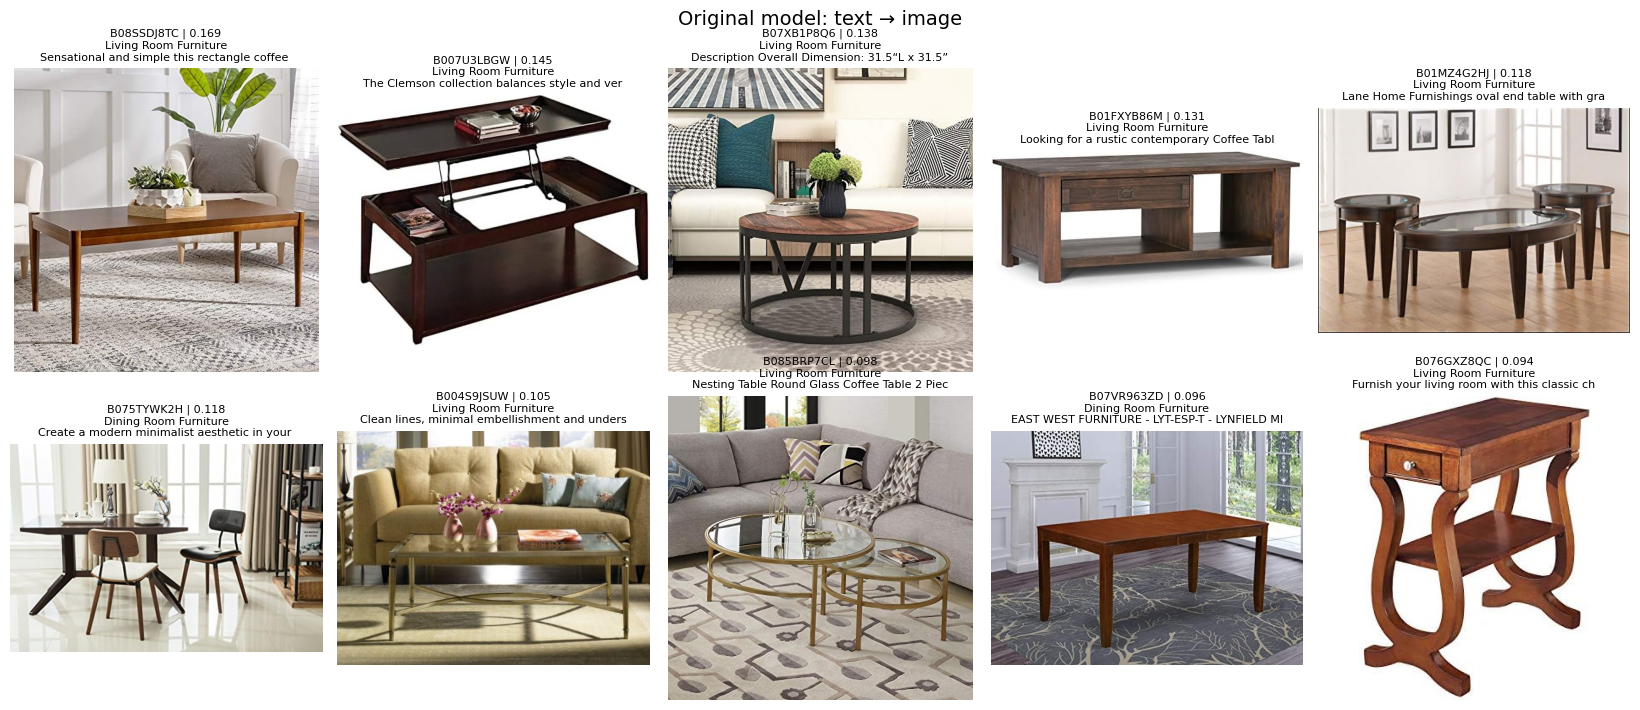

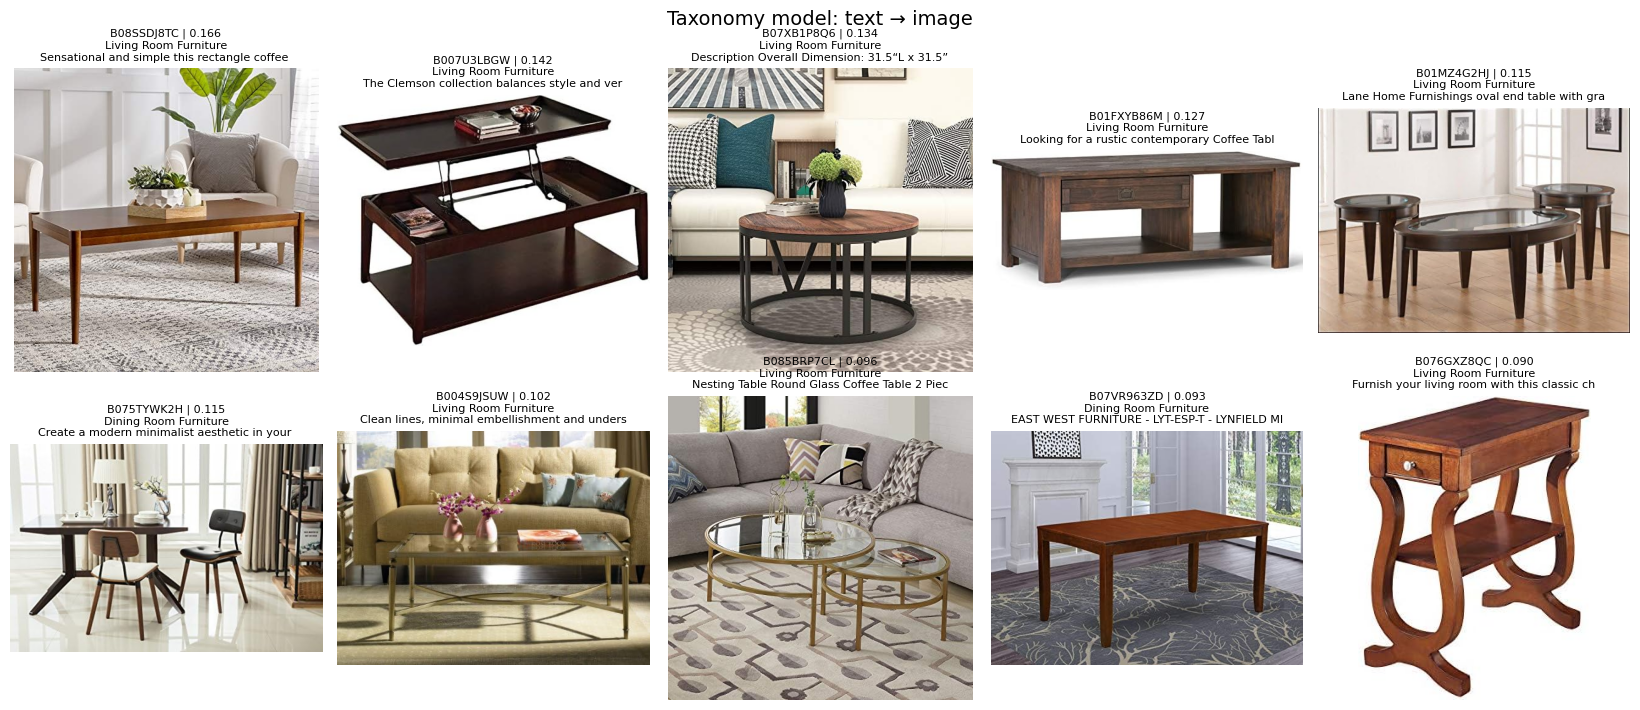

In [11]:
def show_product_grid(results, title, columns=5):
    rows = int(np.ceil(len(results) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(3.3 * columns, 3.6 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, row in zip(axes, results.itertuples()):
        ax.imshow(open_rgb(PROJECT_ROOT / row.image_path))
        ax.set_title(
            f"{row.asin} | {row.score:.3f}\n{row.furniture_subcategory}\n{row.description_original[:45]}",
            fontsize=8,
        )
        ax.axis("off")
    for ax in axes[len(results):]:
        ax.axis("off")
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    return fig


print("Natural text query:", TEXT_QUERY)
print("Model A — original training text")
display(original_result["text_query_results"])
show_product_grid(original_result["text_query_results"], "Original model: text → image");
print("Model B — taxonomy-enriched training text")
display(taxonomy_result["text_query_results"])
show_product_grid(taxonomy_result["text_query_results"], "Taxonomy model: text → image");

query_asin = catalog_df.iloc[0]["asin"]
print("Shared image query ASIN:", query_asin)
display(original_result["image_query_results"])
display(taxonomy_result["image_query_results"])

## 8. Save aligned comparison artifacts

In [12]:
primary_comparison.to_csv(ARTIFACT_DIR / "primary_original_text_metrics.csv")
secondary_comparison.to_csv(ARTIFACT_DIR / "secondary_enriched_text_metrics.csv")
category_neighbor_comparison.to_csv(ARTIFACT_DIR / "category_neighbor_metrics.csv")
catalog_df[CATALOG_COLUMNS].to_csv(ARTIFACT_DIR / "embedding_catalog.csv", index=False)
for result in (original_result, taxonomy_result):
    name = result["variant"]
    np.save(ARTIFACT_DIR / f"{name}_image_embeddings.npy", result["image_embeddings"].numpy())
    np.save(
        ARTIFACT_DIR / f"{name}_description_embeddings.npy",
        result["description_embeddings"].numpy(),
    )
    result["text_query_results"].to_csv(
        ARTIFACT_DIR / f"{name}_text_query_results.csv", index=False
    )
    result["image_query_results"].to_csv(
        ARTIFACT_DIR / f"{name}_image_query_results.csv", index=False
    )

experiment = {
    "model_id": MODEL_ID,
    "seed": SEED,
    "train_rows_per_model": TRAIN_ROWS,
    "evaluation_rows": EVAL_ROWS,
    "catalog_rows": CATALOG_ROWS,
    "epochs": EPOCHS,
    "batch_size": TRAIN_BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "max_text_length": MAX_TEXT_LENGTH,
    "text_query": TEXT_QUERY,
    "baseline_original_metrics": baseline_original_metrics,
    "baseline_enriched_metrics": baseline_enriched_metrics,
    "original_category_neighbor_metrics": original_category_metrics,
    "taxonomy_category_neighbor_metrics": taxonomy_category_metrics,
    "original_variant": {
        key: original_result[key]
        for key in ("training_text_column", "trainable_parameters", "history", "elapsed_seconds", "original_metrics", "enriched_metrics")
    },
    "taxonomy_variant": {
        key: taxonomy_result[key]
        for key in ("training_text_column", "trainable_parameters", "history", "elapsed_seconds", "original_metrics", "enriched_metrics")
    },
}
with (ARTIFACT_DIR / "experiment.json").open("w") as output:
    json.dump(experiment, output, indent=2)
print("Saved:", sorted(path.name for path in ARTIFACT_DIR.iterdir()))
print("Artifact directory:", ARTIFACT_DIR.resolve())

Saved: ['category_neighbor_metrics.csv', 'embedding_catalog.csv', 'experiment.json', 'original_description_embeddings.npy', 'original_heads.pt', 'original_image_embeddings.npy', 'original_image_query_results.csv', 'original_text_query_results.csv', 'primary_original_text_metrics.csv', 'secondary_enriched_text_metrics.csv', 'taxonomy_description_embeddings.npy', 'taxonomy_heads.pt', 'taxonomy_image_embeddings.npy', 'taxonomy_image_query_results.csv', 'taxonomy_text_query_results.csv']
Artifact directory: /Users/vachemacbook/Desktop/RecSystem/RecSystem/models/siglip2_furniture_taxonomy_ab


## Interpretation guardrails

- Prefer the **primary original-text table** when deciding whether taxonomy improved general retrieval.
- Treat enriched-text gains as expected label-assisted behavior, not proof of better natural-language search.
- A 64-pair, one-epoch result is directional only. Repeat with larger training/evaluation sets and multiple seeds before selecting a model.
- Taxonomy can improve category recognition while hurting fine-grained visual/style matching if the model overweights labels. Inspect both metrics and neighbors.
- Because SigLIP2 accepts at most 64 text tokens here, taxonomy displaces some original description tokens. That tradeoff is part of the tested treatment.